**NOTA:**

Artur:

1. análise do conjunto de dados e sua breve descrição  ✅

5. análise preditiva/ aprendizagem de máquina (classificação ou regressão conforme apropriado), comparando o desempenho de vários modelos

Maria:

2. tarefas de pré-processamento dos dados (se julgar necessárias)

6. seleção/ importância das variáveis usadas pelos modelos

Catarina:

3. sumarização dos dados (estatística descritiva, exploração com recurso a gráficos)

4. análise estatística multivariada (não supervisionada): clustering, redução de dimensionalidade/ visualização

# Practical Assignment 2 – Python Application
## 1. Introduction
The goal of this practical assignment is to apply data analysis and knowledge extraction techniques to biological data, with a focus on predicting the mutagenicity of chemical compounds. The task involves developing a complete pipeline in Python, including data loading, preprocessing, exploratory analysis, predictive modeling, and performance evaluation.

The dataset used corresponds to the Ames test, a widely adopted biological assay for identifying compounds with mutagenic potential. It includes a matrix of numerical molecular descriptors (features) and a binary label indicating whether each compound is mutagenic (1) or not (0).

This work provides an opportunity to apply several concepts covered throughout the semester, including multivariate analysis, supervised learning, feature selection, and data visualization.

## 2. Imports

In [521]:
import pandas as pd
import numpy as np
import os
import pprint

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import SelectFromModel
import matplotlib.pyplot as plt



## 3. Assigment Context - Ames Mutagenicity

### Dataset Description: 

Mutagenicity means the ability of a drug to induce genetic alterations. Drugs that can cause damage to the DNA can result in cell death or other severe adverse effects. Nowadays, the most widely used assay for testing the mutagenicity of compounds is the Ames experiment which was invented by a professor named Ames. The Ames test is a short-term bacterial reverse mutation assay detecting a large number of compounds which can induce genetic damage and frameshift mutations. The dataset is aggregated from four papers.

### Task Description: 

Binary classification. Given a drug SMILES string, predict whether it is mutagenic `(1)` or not mutagenic `(0)`.

## 4. Data Exploration with Python

In [522]:
# Load the features dataset
if os.path.exists("/home/arog"):
    features_path = "data_csv/ames_features.csv"
else:
    features_path = "data_csv\\ames_features.csv"
features_df = pd.read_csv(features_path)

# Basic dataset information
features_info = {
    "Shape": features_df.shape,
    "Columns": features_df.columns.tolist(),
    "Missing Values": features_df.isnull().sum().sum(),
    "Preview": features_df.head()
}

print("Dataset Shape:")
pprint.pprint(features_info["Shape"])

Dataset Shape:
(7273, 208)


In [523]:
print("\n Feature Columns (truncated list):")
pprint.pprint(features_info["Columns"])


 Feature Columns (truncated list):
['MaxEStateIndex',
 'MinEStateIndex',
 'MaxAbsEStateIndex',
 'MinAbsEStateIndex',
 'qed',
 'MolWt',
 'HeavyAtomMolWt',
 'ExactMolWt',
 'NumValenceElectrons',
 'NumRadicalElectrons',
 'MaxPartialCharge',
 'MinPartialCharge',
 'MaxAbsPartialCharge',
 'MinAbsPartialCharge',
 'FpDensityMorgan1',
 'FpDensityMorgan2',
 'FpDensityMorgan3',
 'BCUT2D_MWHI',
 'BCUT2D_MWLOW',
 'BCUT2D_CHGHI',
 'BCUT2D_CHGLO',
 'BCUT2D_LOGPHI',
 'BCUT2D_LOGPLOW',
 'BCUT2D_MRHI',
 'BCUT2D_MRLOW',
 'BalabanJ',
 'BertzCT',
 'Chi0',
 'Chi0n',
 'Chi0v',
 'Chi1',
 'Chi1n',
 'Chi1v',
 'Chi2n',
 'Chi2v',
 'Chi3n',
 'Chi3v',
 'Chi4n',
 'Chi4v',
 'HallKierAlpha',
 'Ipc',
 'Kappa1',
 'Kappa2',
 'Kappa3',
 'LabuteASA',
 'PEOE_VSA1',
 'PEOE_VSA10',
 'PEOE_VSA11',
 'PEOE_VSA12',
 'PEOE_VSA13',
 'PEOE_VSA14',
 'PEOE_VSA2',
 'PEOE_VSA3',
 'PEOE_VSA4',
 'PEOE_VSA5',
 'PEOE_VSA6',
 'PEOE_VSA7',
 'PEOE_VSA8',
 'PEOE_VSA9',
 'SMR_VSA1',
 'SMR_VSA10',
 'SMR_VSA2',
 'SMR_VSA3',
 'SMR_VSA4',
 'SMR_VSA

In [524]:
print("Total Missing Values:")
print(features_info["Missing Values"])

Total Missing Values:
0


In [525]:
print("Dataset Preview (first 5 rows):")
features_info["Preview"]

Dataset Preview (first 5 rows):


,MaxEStateIndex,MinEStateIndex,MaxAbsEStateIndex,MinAbsEStateIndex,qed,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,11.663401,-0.396099,11.663401,0.008895,0.181963,342.310,332.230,342.06406,124.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,11.824743,-0.170602,11.824743,0.170602,0.269289,301.345,286.225,301.11030,112.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,14.431072,-0.378575,14.431072,0.128988,0.184582,646.614,628.470,646.11650,232.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,10.422196,-0.670278,10.422196,0.248657,0.103849,157.133,150.077,157.05997,60.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,10.521759,-0.752407,10.521759,0.278148,0.342148,138.086,136.070,138.01778,50.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### **Output**

In [526]:
# Load the features dataset
features_path = "/home/arog/Documents/GitHub/ECDB_Project/trabalho_py/data_csv/ames_outputs.csv"
outputs_df = pd.read_csv(features_path)

# Basic dataset information
features_info = {
    "Shape": outputs_df.shape,
    "Columns": outputs_df.columns.tolist(),
    "Missing Values": outputs_df.isnull().sum().sum(),
    "Preview": outputs_df.head(),
    "Class Distribution": outputs_df['Y'].value_counts().to_dict()
}

print("Dataset Shape:")
pprint.pprint(features_info["Shape"])

Dataset Shape:
(7273, 3)


In [527]:
print("Feature Columns (truncated list):")
pprint.pprint(features_info["Columns"])

Feature Columns (truncated list):
['ids', 'smiles', 'Y']


In [528]:
print("Total Missing Values:")
print(features_info["Missing Values"])

Total Missing Values:
0


In [529]:
print("Dataset Preview (first 5 rows):")
features_info["Preview"]

Dataset Preview (first 5 rows):


,ids,smiles,Y
0,Drug 0,O=[N+]([O-])c1ccc2ccc3ccc([N+](=O)[O-])c4c5ccc...,1
1,Drug 1,O=[N+]([O-])c1c2c(c3ccc4cccc5ccc1c3c45)CCCC2,1
2,Drug 2,O=c1c2ccccc2c(=O)c2c1ccc1c2[nH]c2c3c(=O)c4cccc...,0
3,Drug 3,[N-]=[N+]=CC(=O)NCC(=O)NN,1
4,Drug 4,[N-]=[N+]=C1C=NC(=O)NC1=O,1


In [530]:
print("Class Distribution — 1 = mutagenic, 0 = non-mutagenic:")
pprint.pprint(features_info["Class Distribution"])

Class Distribution — 1 = mutagenic, 0 = non-mutagenic:
{0: 3299, 1: 3974}


## 4. Datasets Overview

This project utilizes two datasets derived from the Ames mutagenicity test: one containing molecular features extracted from chemical structures, and another providing binary mutagenicity classification labels.

---

### Dataset Features

This dataset includes computed molecular descriptors and fragment-based features for each compound, derived from its SMILES (Simplified Molecular Input Line Entry System) representation.

- **Rows (samples)**: 7,273 compounds  
- **Columns (features)**: 208 numerical descriptors  
- **Types of features**:
  - *Physicochemical*: `MolWt`, `TPSA`, `LogP`, `qed`, etc.
  - *Topological and electronic*: `Chi`, `BalabanJ`, `EState`, etc.
  - *Structural fragments (binary flags)*: `fr_nitro`, `fr_urea`, `fr_halogen`, etc.

The dataset contains no missing values and is ready for use in machine learning tasks.

---

### Dataset Output

This dataset contains binary classification labels indicating the mutagenicity of each compound, aligned with the compounds in the feature dataset.

- **Rows**: 7,273 (one per compound)
- **Columns**:
  - `ids`: Unique compound identifier
  - `smiles`: SMILES representation of the compound
  - `Y`: Binary label for mutagenicity  
    - `1` = Mutagenic  
    - `0` = Non-mutagenic

#### Class Distribution

| Label             | Count |
|-------------------|--------|
| Mutagenic (1)     | 3,974  |
| Non-mutagenic (0) | 3,299  |

There are no missing values in the output dataset. The class distribution is slightly imbalanced, with more mutagenic than non-mutagenic samples.

---

Together, these datasets form a complete and clean structure for building supervised learning models to predict the mutagenic potential of chemical compounds.


# Supervised ML

## Code - Random Forest Classifier for Binary Classification

This notebook implements a complete pipeline for:
1. Data preparation
2. Feature selection
3. Model training with hyperparameter tuning
4. Evaluation
5. Feature importance analysis

Configuration

In [531]:
# 1. Initial Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel, RFECV
from sklearn.metrics import (f1_score, confusion_matrix, classification_report, 
                            roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.inspection import permutation_importance
import joblib
from tempfile import mkdtemp
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.datasets import make_classification

# Set random seed for reproducibility
RANDOM_STATE = 100
np.random.seed(RANDOM_STATE)
plt.style.use('seaborn-v0_8')

### 1. Data Loading and Preparation (Comment/Uncomment for pipeline testing)

In [532]:
# Load your data (replace with your actual data loading)
X = features_df
y = outputs_df['Y']

# Create synthetic data for pipline testing (comment if trying real data)
# X, y = make_classification(n_samples=1000, n_features=208, n_informative=50, 
#                           n_redundant=30, random_state=RANDOM_STATE)

# X = pd.DataFrame(X, columns=features_df.columns[:208])  # reuse real names if count matches
# y = pd.Series(y, name='target')

### 2. Exploratory Data Analysis

Features shape: (7273, 208)
Target distribution:
Y
1    0.546405
0    0.453595
Name: proportion, dtype: float64


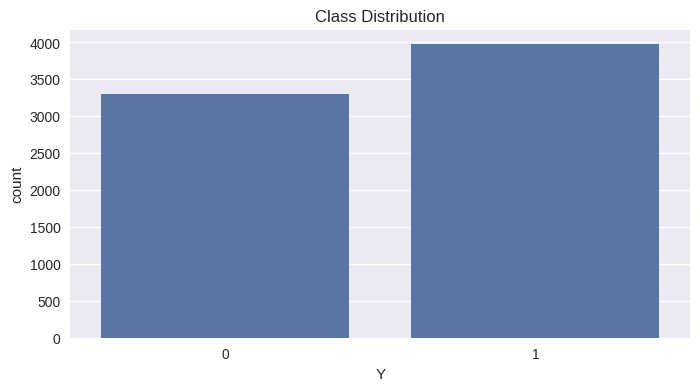

In [533]:
# Basic info
print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True)}")

# Visualize distribution
plt.figure(figsize=(8, 4))
sns.countplot(x=y)
plt.title('Class Distribution')
plt.show()

### 3. Train-Test Split

In [534]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y
)

print(f"Train size: {X_train.shape[0]} samples")
print(f"Test size: {X_test.shape[0]} samples\n")

#Confirm class distribution in each subset
print("Full dataset class distribution:")
print(y.value_counts(normalize=True).rename_axis('Class').reset_index(name='Proportion'))

print("\nTraining set class distribution:")
print(y_train.value_counts(normalize=True).rename_axis('Class').reset_index(name='Proportion'))

print("\nTest set class distribution:")
print(y_test.value_counts(normalize=True).rename_axis('Class').reset_index(name='Proportion'))

Train size: 5818 samples
Test size: 1455 samples

Full dataset class distribution:
   Class  Proportion
0      1    0.546405
1      0    0.453595

Training set class distribution:
   Class  Proportion
0      1    0.546408
1      0    0.453592

Test set class distribution:
   Class  Proportion
0      1    0.546392
1      0    0.453608


### 4. Feature Scaling

In [535]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 5. Baseline Model

In [536]:
# Define evaluation function
def evaluate_model(model, X, y, cv=5):
    cv_scores = cross_val_score(
        model, X, y, 
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE),
        scoring='f1',
        n_jobs=-1
    )
    print(f"F1 Score: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    return cv_scores

# Baseline RF model
baseline_rf = RandomForestClassifier(random_state=RANDOM_STATE)
baseline_scores = evaluate_model(baseline_rf, X_train_scaled, y_train)

F1 Score: 0.845 ± 0.007


### 6. Feature Importance Analysis

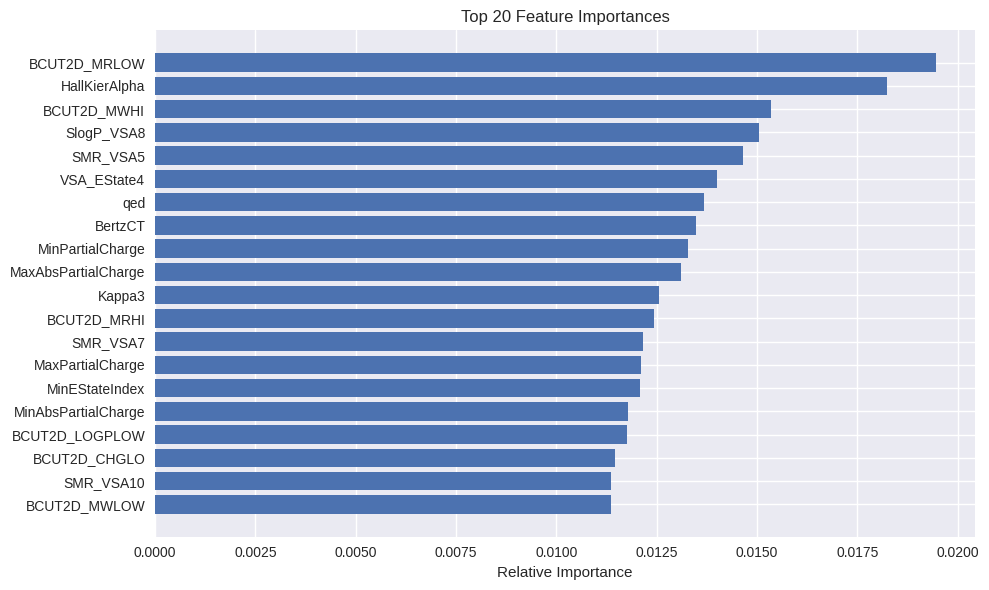

In [537]:
def plot_feature_importance(model, feature_names, top_n=20):
    """Plot feature importance."""
    importances = model.feature_importances_
    indices = np.argsort(importances)[-top_n:]
    
    plt.figure(figsize=(10, 6))
    plt.title(f"Top {top_n} Feature Importances")
    plt.barh(range(top_n), importances[indices], align='center')
    plt.yticks(range(top_n), [feature_names[i] for i in indices])
    plt.xlabel('Relative Importance')
    plt.tight_layout()
    plt.show()

# Fit model to get importances
baseline_rf.fit(X_train_scaled, y_train)
plot_feature_importance(baseline_rf, X_train.columns)

### 7. Feature Selection (Choose one of the options!)

In [538]:
# Option 1: SelectFromModel (faster)
selector = SelectFromModel(
    RandomForestClassifier(random_state=RANDOM_STATE),
    threshold="2.5*median"
)
selector.fit(X_train_scaled, y_train)

X_train_selected = selector.transform(X_train_scaled)
X_test_selected = selector.transform(X_test_scaled)

print(f"Original features: {X_train.shape[1]}")
print(f"Selected features (SelectFromModel): {X_train_selected.shape[1]}")

# Option 2: RFECV (more thorough but slower)
# rfecv = RFECV(
#     estimator=RandomForestClassifier(random_state=RANDOM_STATE),
#     step=1,
#     cv=StratifiedKFold(5),
#     scoring='f1',
#     n_jobs=-1,
#     min_features_to_select=20
# )
# rfecv.fit(X_train_scaled, y_train)

# # Mirror the same variable names as Option 1
# X_train_selected = rfecv.transform(X_train_scaled)
# X_test_selected = rfecv.transform(X_test_scaled)
# selector = rfecv  # Maintain 'selector' name for consistency

# print(f"Original features: {X_train.shape[1]}")
# print(f"Optimal features (RFECV): {rfecv.n_features_}")

Original features: 208
Selected features (SelectFromModel): 42


### 8. Hyperparameter Tuning

In [539]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [4, 6],
    'max_features': ['sqrt', 0.3],
    'class_weight': [None, 'balanced'],
    'bootstrap': [True]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    n_jobs=-1,
    verbose=1 # change for more info
)

grid_search.fit(X_train_selected, y_train)

# Show best parameters
print("Best parameters:")
print(grid_search.best_params_)

# %%
# Get best model
best_model = grid_search.best_estimator_

Fitting 10 folds for each of 144 candidates, totalling 1440 fits
Best parameters:
{'bootstrap': True, 'class_weight': None, 'max_depth': 15, 'max_features': 0.3, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}


### 9. Model Evaluation

Training Performance:
              precision    recall  f1-score   support

           0       0.97      0.94      0.95      2639
           1       0.95      0.97      0.96      3179

    accuracy                           0.96      5818
   macro avg       0.96      0.96      0.96      5818
weighted avg       0.96      0.96      0.96      5818


Test Performance:
[[533 127]
 [139 656]]
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       660
           1       0.84      0.83      0.83       795

    accuracy                           0.82      1455
   macro avg       0.82      0.82      0.82      1455
weighted avg       0.82      0.82      0.82      1455

ROC AUC: 0.894


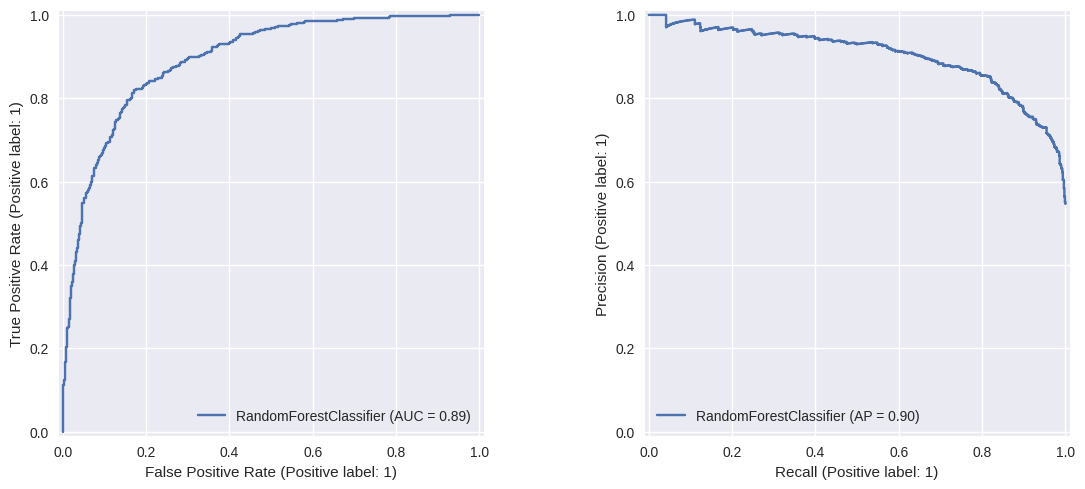

In [540]:
# Training evaluation
train_pred = best_model.predict(X_train_selected)
print("Training Performance:")
print(classification_report(y_train, train_pred))

# Test evaluation
test_pred = best_model.predict(X_test_selected)
test_proba = best_model.predict_proba(X_test_selected)[:, 1]

print("\nTest Performance:")
print(confusion_matrix(y_test, test_pred))
print(classification_report(y_test, test_pred))
print(f"ROC AUC: {roc_auc_score(y_test, test_proba):.3f}")

# Plot curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_estimator(best_model, X_test_selected, y_test, ax=ax1)
PrecisionRecallDisplay.from_estimator(best_model, X_test_selected, y_test, ax=ax2)
plt.tight_layout()
plt.show()

### 10. Feature Importance Analysis

/tmp/ipykernel_5553/635373596.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


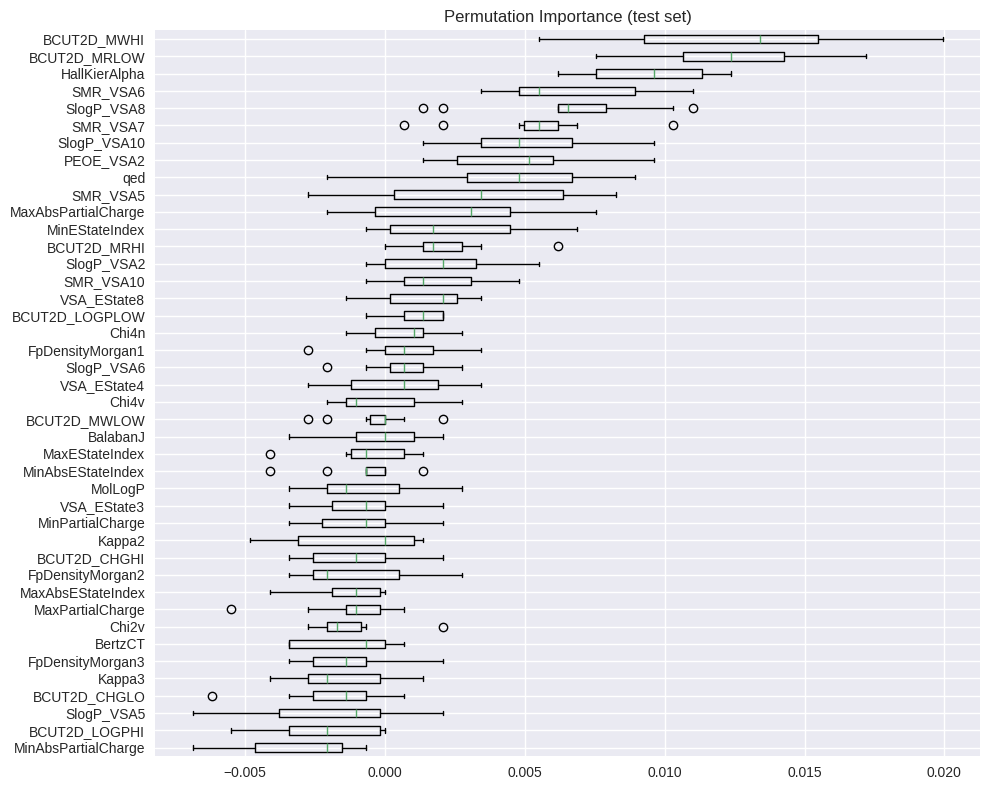

In [541]:
# Permutation importance
result = permutation_importance(
    best_model, X_test_selected, y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
# Limit to top 50 important features
sorted_idx = result.importances_mean.argsort()
plt.figure(figsize=(10, 8))
plt.boxplot(
    result.importances[sorted_idx[:50]].T,
    vert=False,
    labels=np.array(X_train.columns[selector.get_support()])[sorted_idx[:50]]
)
plt.title("Permutation Importance (test set)")
plt.tight_layout()
plt.show()

### 11. Save Model

In [542]:
# Save all components
joblib.dump(best_model, 'best_rf_model.pkl')
joblib.dump(selector, 'feature_selector.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')

# Create dictionary with all components
model_artifacts = {
    'model': best_model,
    'selector': selector,
    'scaler': scaler,
    'feature_names': X_train.columns.tolist()
}

joblib.dump(model_artifacts, 'model_artifacts.pkl')

['model_artifacts.pkl']

## Analysis